<h1>KI-Tutorial : Ziffererkennung mit Python</h1>

Dieses Tutorial ist als Einstieg in das Thema Deep Learning mit Python gedacht. Sie lernen in wenigen einfachen Schritten, wie Sie ein neuronales Netzwerk erzeugen und trainieren. Der Trainingsdatensatz ist so einfach, dass Sie ihn innerhalb weniger Sekunden auf einem normalen PC oder Laptop trainieren können. 


<h2>Daten sind die Grundlage des maschinellen Lernens! </h2>

Die Qualität Ihrer Daten bestimmt, wie gut die trainierte KI die Aufgabe lösen wird. Selbst das beste neuronale Netzwerk wird niemals ein gutes Ergebnis liefern, wenn es mit falschen oder unzureichenden Daten trainiert wurde! Das Auffinden und Verarbeiten der Daten ist einer der zeitaufwändigsten Schritte bei der Entwicklung von KI-Systemen. Für dieses Tutorial verfolgen wir allerdings einen viel einfacheren Ansatz: Wir verwenden einen Datensatz, der bereits für das Training erstellt wurde.

<h2>Der Digits-Datensatz</h2>

Unser Trainingsdatensatz stammt aus SCIKIT LEARN. Scikit-learn ist eine kostenlose Softwarebibliothek für maschinelles Lernen für die Programmiersprache Python. Sie bietet verschiedene Klassifizierungs-, Regressions- und Clustering-Algorithmen. Der Datensatz „Digits“ besteht aus 8x8-Pixel-Bildern von Ziffern. Das Attribut „images“ des Datensatzes speichert 8x8-Arrays von Graustufenwerten für jedes Bild. Das Attribut „target“ des Datensatzes speichert die Ziffer, die jedes Bild darstellt. 

Der Datensatz sieht visualisiert so aus:

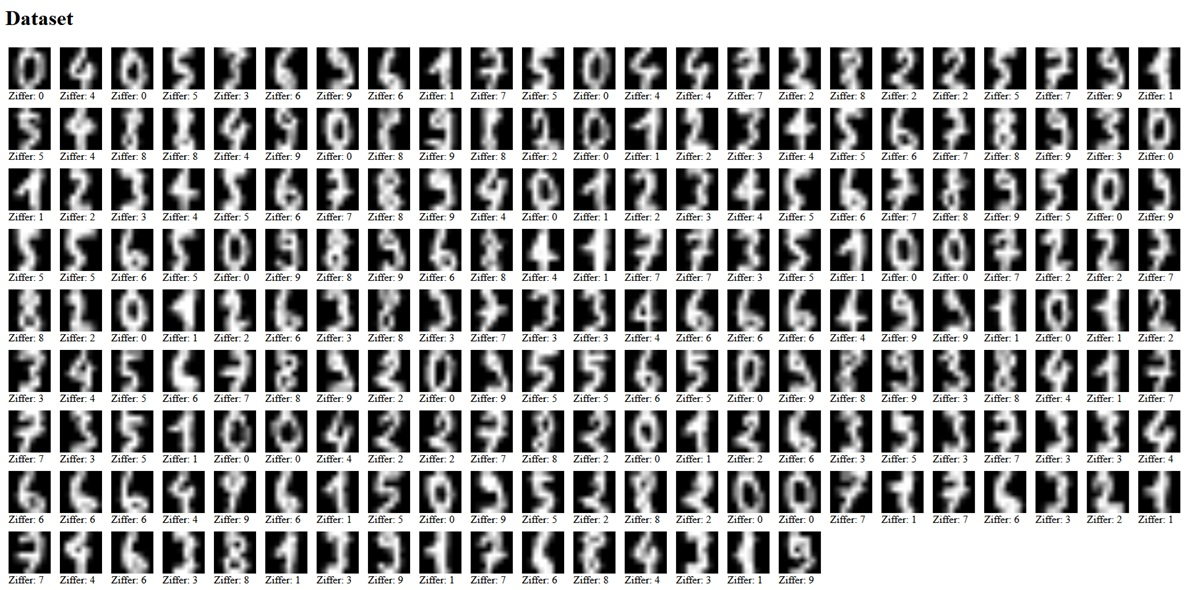

<h2>Laden Des Datensatzes</h2>

Zunächst muss die SCIKIT LEARN Bibliothek geladen werden:

In [ ]:
pip install scikit-learn

Danach kann man den Datensatz ganz einfach laden:

In [1]:
from sklearn import datasets

digits = datasets.load_digits()

<h2>Den Datensatz visualisieren</h2>
Um uns den Datensatz genauer ansehen zu können, speichern wir die ersten 200 Bilder als PNG-Dateien in einem Unterordner „bilder”:

In [4]:
import os
os.mkdir("bilder")

Zudem müssen wir die Bibliothek "matplotlib" installierten:

In [2]:
import matplotlib.pyplot as plt

In [5]:
# Speichere die ersten 200 Bilder
for i in range(200):
    image = digits.images[i]
    label = digits.target[i]
    filename = "bilder/bild" + str(i) + "_" + str(label) + ".png"
    plt.imsave(filename, image, cmap='gray')

print("Bilder gespeichert!")

Bilder gespeichert!


Wir können den Datensatz auch als Webseite visualisieren. Das Programm generiert eine Webseite namens „datensatz.html“ und zeigt die 200 Bilder mit den entsprechenden Beschriftungen an. 

In [6]:
import os

# Es wird ein HTML Dokument , also eine Webseite erstellt
html_code = [ "<html<body>", "<h1>Dataset</h1>" ]

# Lesen aller Dateien im Verzeichnis Bilder
files = os.listdir("bilder")
# Erzeugung des HTML Quellcodes
for file in files:
    #print(file)
    # für jede Datei wird ein div - Element erzeugt, das das Bild und das Label enthält
    label = file[-5]
    html_code.append(f'<div style="display:inline-block; margin:5px;">')
    html_code.append(f'<img src="bilder/{file}" style="width:64px; height:64px;"><br>')
    html_code.append(f'Ziffer: {label}')
    html_code.append('</div>')
    html_code.append('\n')
html_code.append("")
html_code.append("</body></html>")

# Schreiben des HTML Quellcodes in eine Datei namens "datensatz.html"

f = open("datensatz.html", "w")
for line in html_code:
    f.write(line)
    

<h2>Ein Modell Auswählen</h2>

Nun müssen wir ein passendes Neuronales Netz auswählen. Normalerweise würde man für ein Bildverarbeitung ein CNN verwenden, da dieser Datensatz aber sehr einfach zu lernen ist, genügt ein Feed - Forward - Netz mit nur einer hidden - layer mit 50 Neuronen. 

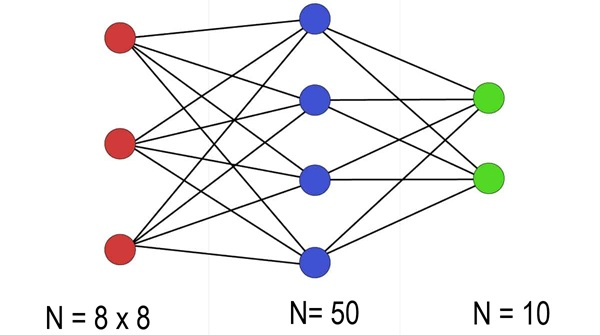

Das hier verwendete Modell ist der MLPClassifier:

* Es ist ein Feedforward-Netzwerk
* Es hat mindestens 3 Schichten: Eingabeschicht → versteckte Schicht(en) → Ausgabeschicht
* Signale fließen nur in eine Richtung (keine Rückkopplungen, kein RNN)


* ACHTUNG: Die Anzahl der Neuronen in der Eingangsschicht entspricht der Anzahl der Merkmale (Features) deiner Eingabedaten.
* die Anzahl der Neuronen der Ausgangsschicht  wird automatisch anhand der Zielwerte (y) beim Training festgelegt.
* max_iter = Anzahl der maximalen Epochen
* Wenn das Modell vorher schon gut genug ist, kann es aber auch früher stoppen (abhängig von tol und early_stopping).
* tol steht für Tolerance (Toleranz) und gibt an, ab welchem minimalen Verbesserungswert das Training als „konvergiert“ gilt und gestoppt wird.

In [7]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500)
params = model.get_params()
for key, value in params.items():
    print(key + " : " + str(value))

activation : relu
alpha : 0.0001
batch_size : auto
beta_1 : 0.9
beta_2 : 0.999
early_stopping : False
epsilon : 1e-08
hidden_layer_sizes : (50,)
learning_rate : constant
learning_rate_init : 0.001
max_fun : 15000
max_iter : 500
momentum : 0.9
n_iter_no_change : 10
nesterovs_momentum : True
power_t : 0.5
random_state : None
shuffle : True
solver : adam
tol : 0.0001
validation_fraction : 0.1
verbose : False
warm_start : False


In [ ]:
# Parameter	            Bedeutung	                                                    Standardwert
#hidden_layer_sizes	    Tuple mit der Größe jeder versteckten Schicht (z. B. (100,))	(100,)
#activation	            Aktivierungsfunktion: 'relu', 'tanh', 'logistic', 'identity'	'relu'
#solver	                Optimierer:     'adam', 'sgd', 'lbfgs'	                        'adam'
#alpha	                L2-Regularisierung (Gewichtungsbestrafung)	                    0.0001
#batch_size	            Größe der Mini-Batches (int oder 'auto')	                    'auto'
#learning_rate	        Lernratenstrategie: 'constant', 'invscaling', 'adaptive'	    'constant'
#learning_rate_init	    Anfangslernrate	                                                0.001
#max_iter   	        Maximale Anzahl Iterationen (Epochen)	                        200
#tol	                Toleranz für Optimierungsstopp	                                1e-4
#early_stopping	        Frühzeitiges Stoppen bei stagnierender Leistung (nur mit adam/sgd)	False
#shuffle	            Trainingsdaten bei jedem Durchgang mischen	                    True
#random_state	        Zufallsstart reproduzierbar machen	                            None
#momentum	            Nur bei sgd: Momentum-Faktor	                                0.9
#n_iter_no_change	    Anzahl Iterationen ohne Verbesserung bis Stop	                10
#verbose	            Trainingsfortschritt ausgeben	                                False

<h2>Den Datensatz für das Training vorbereiten</h2>

Vor dem Training werden die Daten in Trainings- und Testdaten aufgeteilt. Diese ist ein zentraler Bestandteil des maschinellen Lernens. Hier eine kurze Erklärung mit Begründungen:

Trainingsdaten: Diese Daten werden vom Modell verwendet, um Muster zu lernen – also die „Lernphase”. 
Testdaten: Diese Daten werden nach dem Training des Modells verwendet, um die Leistung zu bewerten – ohne dass das Modell diese Daten zuvor gesehen hat. Warum ist das wichtig? Um Überanpassung zu vermeiden. Wenn Sie das Modell mit allen verfügbaren Daten trainieren, könnte es sich die Daten einfach „merken”, anstatt echte Muster zu lernen. Dies wird als Überanpassung (Overfitting) bezeichnet. Das Modell würde dann bei den Trainingsdaten gut abschneiden, bei neuen Daten jedoch schlecht. Testdaten sind die einzige Möglichkeit, wirklich zu beurteilen, wie gut das Modell mit unbekannten Daten – also in der Realität – funktioniert. Die übliche Aufteilung ist 70 bis 80 % Trainings- und 20 bis 30 % Testdaten. Wir verwenden hier eine 30/70-Aufteilung. 

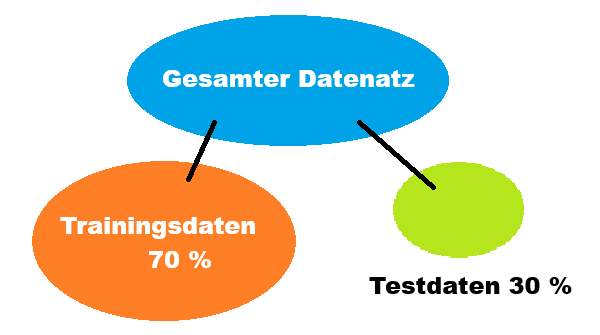

Das folgende Programm teilt die Daten und die Labels 70 zu 30 auf und gibt die Anzahl der jeweiligen Bilder und Labels aus.


In [8]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Datensatz laden
digits = datasets.load_digits()


# 70% sind Trainingsdaten, 30% sind Testdaten
bilder_train, bilder_test, labels_train, labels_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=42)

print("Bilder für das Training: " , len(bilder_train) )
print(bilder_train)
print("Labels für das Training: " , len(labels_train))
print(labels_train)
print("Bilder für den Test:  " , len(bilder_test) )
print(bilder_train)
print("Labels für den Test:" , len(labels_test))
print(labels_train)

Bilder für das Training:  1257
[[ 0.  0.  5. ... 10.  0.  0.]
 [ 0.  0.  3. ...  0.  0.  0.]
 [ 0.  0.  5. ... 16. 11.  2.]
 ...
 [ 0.  0.  9. ... 16.  2.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 [ 0.  0.  1. ...  1.  0.  0.]]
Labels für das Training:  1257
[8 7 1 ... 2 7 1]
Bilder für den Test:   540
[[ 0.  0.  5. ... 10.  0.  0.]
 [ 0.  0.  3. ...  0.  0.  0.]
 [ 0.  0.  5. ... 16. 11.  2.]
 ...
 [ 0.  0.  9. ... 16.  2.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 [ 0.  0.  1. ...  1.  0.  0.]]
Labels für den Test: 540
[8 7 1 ... 2 7 1]


<h2>Den Datensatz trainieren</h2>

Nun kommt der zentrale Teil bei der Entwicklung eines KI Systems: Dem Training des Neuronalen Netzes. Das Training kann je nach Datensatz durchaus komplex sein, nicht jeder Trainingsdurchgang ist sofort von Erfolg gekrönt. Typische Einflussgrößen auf den Lernerfolg sind das gewählte Modell an sich, die Lernrate, der verwendete Optimizer und die Anzahl der Epochen. Darüber hinaus gibt es noch eine Menge von Techniken, die vor allem das Overfitting verhindern soll, diese sprengen aber den Rahmen dieses Tutorials.

Das Training ist bei diesem Beispiel maximal einfach: Wir legen die maximale Anzahl der Epochen im Modell fest, rufen die Methode „fit“ auf und übergeben die Trainingsdaten und Labels. Der Parameter „verbose“ sorgt für eine Ausgabe des Trainingsfortschritts.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split
import joblib

# Datensatz laden
digits = datasets.load_digits()

# 70% sind Trainingsdaten, 30% sind Testdaten
bilder_train, bilder_test, labels_train, labels_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=42)

# Modell erzeugen: 50 neuronen in der hidden layer
model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, verbose = True)

# Training
model.fit(bilder_train, labels_train)


<h2>Überprüfung des Lernerfolges</h2>

Die Qualität des Trainings läßt sich in unserem Fall sehr einfach überprüfen: man setzt einfach die Anzahl der richtig klassifizierten Bilder in Relation zur Gesamtanzahl und gibt diese als Prozentwert an. Dies wird getrennt für die Trainingsdaten und die Testdaten gemacht:

In [ ]:
# Auswertung
print("Genauigkeit mit Trainingsdaten :", model.score(bilder_train, labels_train))
print("Genauigkeit mit Testdaten :", model.score(bilder_test, labels_test))

<h2>Speichern des trainierten Netzes</h2>

Üblicherweise dauert das Training komplexerer Netze viele Stunden oder gar Tage. Somit ist es absolut sinnvoll, trainierte Netze abzuspeichern. Dazu verwenden wir die Bibliothek "joblib":


In [ ]:
pip install joblib

In [ ]:
pip install joblib

In [ ]:
import joblib

Zum Speichern steht dier Methode "dump" zur Verfügung, die das Netz im aktuellen Zustand inkl. aller Gewichte in eine Date speichert:  

In [ ]:
# Modell speichern
joblib.dump(model, 'digits_model.pkl')

<h2>Realtest</h2>

Mit dem folgenden Programm kann man einen Test unter realistischen Bedingugen durchführen: Man zeichnet eine Ziffer in die sich öffnende Zeichenfläche und kann diese Ziffer vom vortrainierten Netz klassifizieren lassen. Für die Oberfäche wurde die Bibliothek "PyQt5" verwendet, die zunächst noch installiert werden muss:

In [ ]:
pip install pyqt5

<h3>Konvertierungen</h3>

Das QImage - Bildformat kann von unserem trainierten Netz nicht direkt verarbeitet werden und muss entsprechend über mehrere Stufen in das passende Format (Vektor der Dimension 1 x 64) konvertiert werden. 

Das QImage-Format wurde verwendet, da es sich gut in die PyQT5-Schnittstelle integrieren lässt. Leider eignet es sich nur schlecht für die weitere Verarbeitung. Das PIL-Bildformat wäre besser geeignet. Eine direkte Konvertierung zwischen den beiden Formaten ist relativ komplex, daher wird ein einfacher Trick angewendet: Man speichert das QImage als PNG und lädt die PNG-Datei anschließend in das PIL-Bildformat. 

self.image.save("pic.png")
img = Image.open("pic.png").convert("L")    

Die Methode „convert“ wandelt das RGB-Bild in ein Bild mit 256 Graustufen um. 

img = img.resize((8,8))   

Nun haben wir ein Bild mit einer Größe von 8 x 8 Pixeln, aber es ist immer noch ein Bild. Da wir letztendlich einen Vektor mit den Abmessungen 1 x 64 benötigen, wandeln wir das Bild als Zwischenschritt in ein 8 x 8-Array um. 

img_data = np.array(img)

Unser Array enthält zwar noch Daten für Pixel mit 256 Graustufen, doch die Trainingsdaten umfassen nur 16 Graustufen. Glücklicherweise ist die Umrechnung von 256 auf 16 ganz einfach: Man muss nur durch 16 teilen! 

img_data = img_data / 16

Nun sind wir fast fertig: Das 8×8-Array muss nur noch in einen 1×64-Vektor umgewandelt werden, was mithilfe der „flatten“-Methode von numpy erfolgt. 

img_data = img_data.flatten().reshape(1, -1)

<h2>Das Testprogramm</h2>

In [ ]:
import sys
from PyQt5.QtWidgets import QApplication, QWidget, QPushButton, QVBoxLayout
from PyQt5.QtGui import QPainter, QPen, QImage
from PyQt5.QtCore import Qt, QPoint
import numpy as np
from PIL import Image
import joblib

class Ziffern_Test(QWidget):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("Test auf Digitalen Ziffern")
        self.setGeometry(100, 100, 300, 350)

        # Bild auf dem gezeichnet wird
        self.image = QImage(280, 280, QImage.Format_RGB32)
        self.image.fill(Qt.black)

        self.drawing = False
        self.last_point = QPoint()

        # Button für Überprüfung
        self.button = QPushButton("Check")
        self.button.clicked.connect(self.check_digit)

        # Vertikales Layout erstellen
        layout = QVBoxLayout()
        layout.addStretch()
        layout.addWidget(self.button)
        self.setLayout(layout)

        # Modell laden
        self.model = joblib.load('digits_model.pkl')

    def mousePressEvent(self, event):
        self.drawing = True
        self.last_point = event.pos()

    def mouseMoveEvent(self, event):
        if self.drawing:
            painter = QPainter(self.image)
            pen = QPen(Qt.white, 20, Qt.SolidLine, Qt.RoundCap, Qt.RoundJoin)
            painter.setPen(pen)
            painter.drawLine(self.last_point, event.pos())
            self.last_point = event.pos()
            # trigger paint event
            self.update()

    def mouseReleaseEvent(self, event):
        self.drawing = False

    def paintEvent(self, event):
        canvas = QPainter(self)
        canvas.drawImage(10, 10, self.image)

    def check_digit(self):
        # Konvertierung des Qimage in ein PIL Image:
        # Das Bild wird als PNG gespeichert
        self.image.save("pic.png")

        # Das gespeicherte Bild wird als PIL IMage geladen
        # das convert("L") lädt das Bild mit 256 Graustufen
        img = Image.open("pic.png").convert("L")
        # Das Bild muss auf 8x8 Pixel reduziert werden, damit es mit den
        # Trainingsdaten übereinstimmt
        img = img.resize((8,8))
        # Das Bild wird in ein 8x8 Array konvertiert
        img_data = np.array(img)
        # Das Bild wird von 256 Graustufen auf 16 Graustufen konvertiert
        img_data = img_data / 16
        # Das 8x8 Array wird in ein 1 x 64 Array konverteirt
        img_data = img_data.flatten().reshape(1, -1)
        # Das konvertierte Bild wird in das NN Netz geladen und das Netz macht seine Vorhersage
        prediction = self.model.predict(img_data)
        print("Vorhersage:" + str(prediction[0]))

        # Für neue Zeichnung leeren
        self.image.fill(Qt.black)
        self.update()

if __name__ == "__main__":
    app = QApplication(sys.argv)
    fenster = Ziffern_Test()
    fenster.show()
    sys.exit(app.exec_())


